# Part 3 – Machine Learning and AI
## Final Execution Notebook: Tasks 1–6

This notebook provides a clean, reproducible execution record for Part 3 Tasks 1–6.

**Important accident-data limitation:** No accident dataset was supplied. The classification target `high_risk` is therefore a **documented proxy label** based on high/severe congestion occurring with severe or low-visibility weather. It is used only to demonstrate the classification workflow and **must not be interpreted as prediction of actual accidents**.

Task 7 (Responsible and Sustainable AI) is submitted separately as a report.

## 0. Setup and Project Structure

The notebook expects these final scripts and the verified Part 2 cleaned dataset to be available in `/content` or uploaded when this notebook is started.

In [18]:
from pathlib import Path
import os

BASE = Path("/content/capstone_part3")
for folder in ["data", "models", "results", "figures", "logs"]:
    (BASE / folder).mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE)
print("Existing files in /content:")
for p in sorted(Path("/content").glob("*")):
    print(" -", p.name)


Project directory: /content/capstone_part3
Existing files in /content:
 - .config
 - capstone_part3
 - sample_data
 - task1_supervised_models.py
 - task2_unsupervised.py
 - task3_deep_learning.py
 - task4_mlflow.py
 - task5_recommendation.py
 - task6_api.py
 - task6_api_test.py
 - task6_mlop.py
 - traffic_cleaned.csv


In [19]:
# Optional upload helper for a clean Colab runtime.
# Upload the verified cleaned dataset plus the final Task 1–6 scripts if they are not already present.

from pathlib import Path
from google.colab import files

required = [
    "traffic_cleaned.csv",
    "task1_supervised_models.py",
    "task2_unsupervised.py",
    "task3_deep_learning.py",
    "task4_mlflow.py",
    "task5_recommendation.py",
    "task6_mlop.py",
    "task6_api.py",
    "task6_api_test.py",
]
missing = [f for f in required if not Path("/content", f).exists()]
print("Missing files:", missing)
if missing:
    print("Select the missing files in the upload dialog.")
    uploaded = files.upload()
    print("Uploaded:", list(uploaded.keys()))
else:
    print("All required files are already available.")


Missing files: []
All required files are already available.


In [20]:
# Copy required files into the Part 3 project folder.
from shutil import copy2

for name in [
    "traffic_cleaned.csv",
    "task1_supervised_models.py",
    "task2_unsupervised.py",
    "task3_deep_learning.py",
    "task4_mlflow.py",
    "task5_recommendation.py",
    "task6_mlop.py",
    "task6_api.py",
    "task6_api_test.py",
]:
    src = Path("/content") / name
    if src.exists():
        copy2(src, BASE / name)

print("Part 3 project setup complete.")
for p in sorted(BASE.iterdir()):
    print(" -", p.name)


Part 3 project setup complete.
 - data
 - figures
 - logs
 - models
 - results
 - task1_supervised_models.py
 - task2_unsupervised.py
 - task3_deep_learning.py
 - task4_mlflow.py
 - task5_recommendation.py
 - task6_api.py
 - task6_api_test.py
 - task6_mlop.py
 - traffic_cleaned.csv


In [21]:
from pathlib import Path
import shutil

BASE = Path("/content/capstone_part3")
DATA_DIR = BASE / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

src = Path("/content/traffic_cleaned.csv")
dst = DATA_DIR / "traffic_cleaned.csv"

if not src.exists():
    raise FileNotFoundError("traffic_cleaned.csv is not present in /content.")

shutil.copy2(src, dst)

print(f"Copied: {src}")
print(f"To:     {dst}")
print(f"Size:   {dst.stat().st_size:,} bytes")

Copied: /content/traffic_cleaned.csv
To:     /content/capstone_part3/data/traffic_cleaned.csv
Size:   3,187,672 bytes


In [22]:
!ls -lh /content/capstone_part3/data/traffic_cleaned.csv

-rw-r--r-- 1 root root 3.1M Sep 24 13:54 /content/capstone_part3/data/traffic_cleaned.csv


# Task 1 – Supervised Machine Learning

**Classification:** Logistic Regression and Random Forest Classifier.  
**Regression:** Linear Regression and HistGradientBoosting Regressor.

Classification is evaluated with Accuracy, Precision, Recall, F1 and ROC AUC. Regression is evaluated with MAE and R². The proxy `high_risk` label is created from the assignment-defined congestion/weather logic.

In [23]:
%cd /content/capstone_part3
!python task1_supervised_models.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --log logs/task1.log \
  --log-level DEBUG


/content/capstone_part3
2026-09-24 14:08:09 | INFO | __main__ | Part 3 Task 1 supervised modelling started
2026-09-24 14:08:09 | INFO | __main__ | Proxy-label note: no accident dataset was supplied; high_risk is a documented proxy only
2026-09-24 14:08:09 | INFO | __main__ | Loaded supervised-learning input: 48187 rows x 9 columns
2026-09-24 14:08:09 | INFO | __main__ | Proxy high-risk label created: 5438 positive / 42749 negative
2026-09-24 14:08:09 | DEBUG | __main__ | Congestion quartiles: Q1=1192.500, Q2=3379.000, Q3=4933.000
2026-09-24 14:08:09 | DEBUG | __main__ | SEVERE_WEATHER definition used: ['Fog', 'Snow', 'Squall', 'Thunderstorm']
2026-09-24 14:08:09 | INFO | __main__ | Train/test split created: train=38549, test=9638
2026-09-24 14:08:10 | INFO | __main__ | Saved classification model: models/logistic_regression.joblib
2026-09-24 14:08:16 | INFO | __main__ | Saved classification model: models/random_forest_classifier.joblib
2026-09-24 14:08:16 | INFO | __main__ | Saved regre

In [24]:
%cd /content/capstone_part3

!cp -f /content/task1_supervised_models.py .
!ls -lh task1_supervised_models.py

/content/capstone_part3
-rw-r--r-- 1 root root 11K Sep 24 14:08 task1_supervised_models.py


In [25]:
!python task1_supervised_models.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --log logs/task1.log \
  --log-level DEBUG

2026-09-24 14:08:24 | INFO | __main__ | Part 3 Task 1 supervised modelling started
2026-09-24 14:08:24 | INFO | __main__ | Proxy-label note: no accident dataset was supplied; high_risk is a documented proxy only
2026-09-24 14:08:24 | INFO | __main__ | Loaded supervised-learning input: 48187 rows x 9 columns
2026-09-24 14:08:24 | INFO | __main__ | Proxy high-risk label created: 5438 positive / 42749 negative
2026-09-24 14:08:24 | DEBUG | __main__ | Congestion quartiles: Q1=1192.500, Q2=3379.000, Q3=4933.000
2026-09-24 14:08:24 | DEBUG | __main__ | SEVERE_WEATHER definition used: ['Fog', 'Snow', 'Squall', 'Thunderstorm']
2026-09-24 14:08:24 | INFO | __main__ | Train/test split created: train=38549, test=9638
2026-09-24 14:08:25 | INFO | __main__ | Saved classification model: models/logistic_regression.joblib
2026-09-24 14:08:32 | INFO | __main__ | Saved classification model: models/random_forest_classifier.joblib
2026-09-24 14:08:32 | INFO | __main__ | Saved regression model: models/line

In [26]:
!ls -lh results/task1_model_metrics.csv
!ls -lh figures/task1_model_comparison.png
!ls -lh logs/task1.log

-rw-r--r-- 1 root root 481 Sep 24 14:08 results/task1_model_metrics.csv
-rw-r--r-- 1 root root 53K Sep 24 14:08 figures/task1_model_comparison.png
-rw-r--r-- 1 root root 12K Sep 24 14:08 logs/task1.log


In [27]:
!cat /content/capstone_part3/logs/task1.log

2026-09-24 13:58:03 | INFO | __main__ | Part 3 Task 1 supervised modelling started
2026-09-24 13:58:03 | INFO | __main__ | Proxy-label note: no accident dataset was supplied; high_risk is a documented proxy only
2026-09-24 13:58:03 | ERROR | __main__ | Part 3 Task 1 failed: Input dataset not found: data/traffic_cleaned.csv
Traceback (most recent call last):
  File "/content/capstone_part3/task1_supervised_models.py", line 61, in load_data
    df = pd.read_csv(path, keep_default_na=False)
  File "/usr/local/lib/python3.13/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/usr/local/lib/python3.13/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/usr/local/lib/python3.13/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^


In [28]:
import pandas as pd

metrics = pd.read_csv(
    "/content/capstone_part3/results/task1_model_metrics.csv"
)

display(metrics)

,task,model,accuracy,precision,recall,f1,roc_auc,mae,r2
0,classification,logistic_regression,0.965553,0.774709,0.979779,0.865260,0.993483,NaN,NaN
1,classification,random_forest_classifier,0.986719,0.936364,0.946691,0.941499,0.998167,NaN,NaN
2,regression,linear_regression,NaN,NaN,NaN,NaN,NaN,818.030813,0.714874
3,regression,hist_gradient_boosting_regressor,NaN,NaN,NaN,NaN,NaN,257.601709,0.950677


In [29]:
import pandas as pd
metrics = pd.read_csv("/content/capstone_part3/results/task1_model_metrics.csv")
display(metrics)


,task,model,accuracy,precision,recall,f1,roc_auc,mae,r2
0,classification,logistic_regression,0.965553,0.774709,0.979779,0.865260,0.993483,NaN,NaN
1,classification,random_forest_classifier,0.986719,0.936364,0.946691,0.941499,0.998167,NaN,NaN
2,regression,linear_regression,NaN,NaN,NaN,NaN,NaN,818.030813,0.714874
3,regression,hist_gradient_boosting_regressor,NaN,NaN,NaN,NaN,NaN,257.601709,0.950677


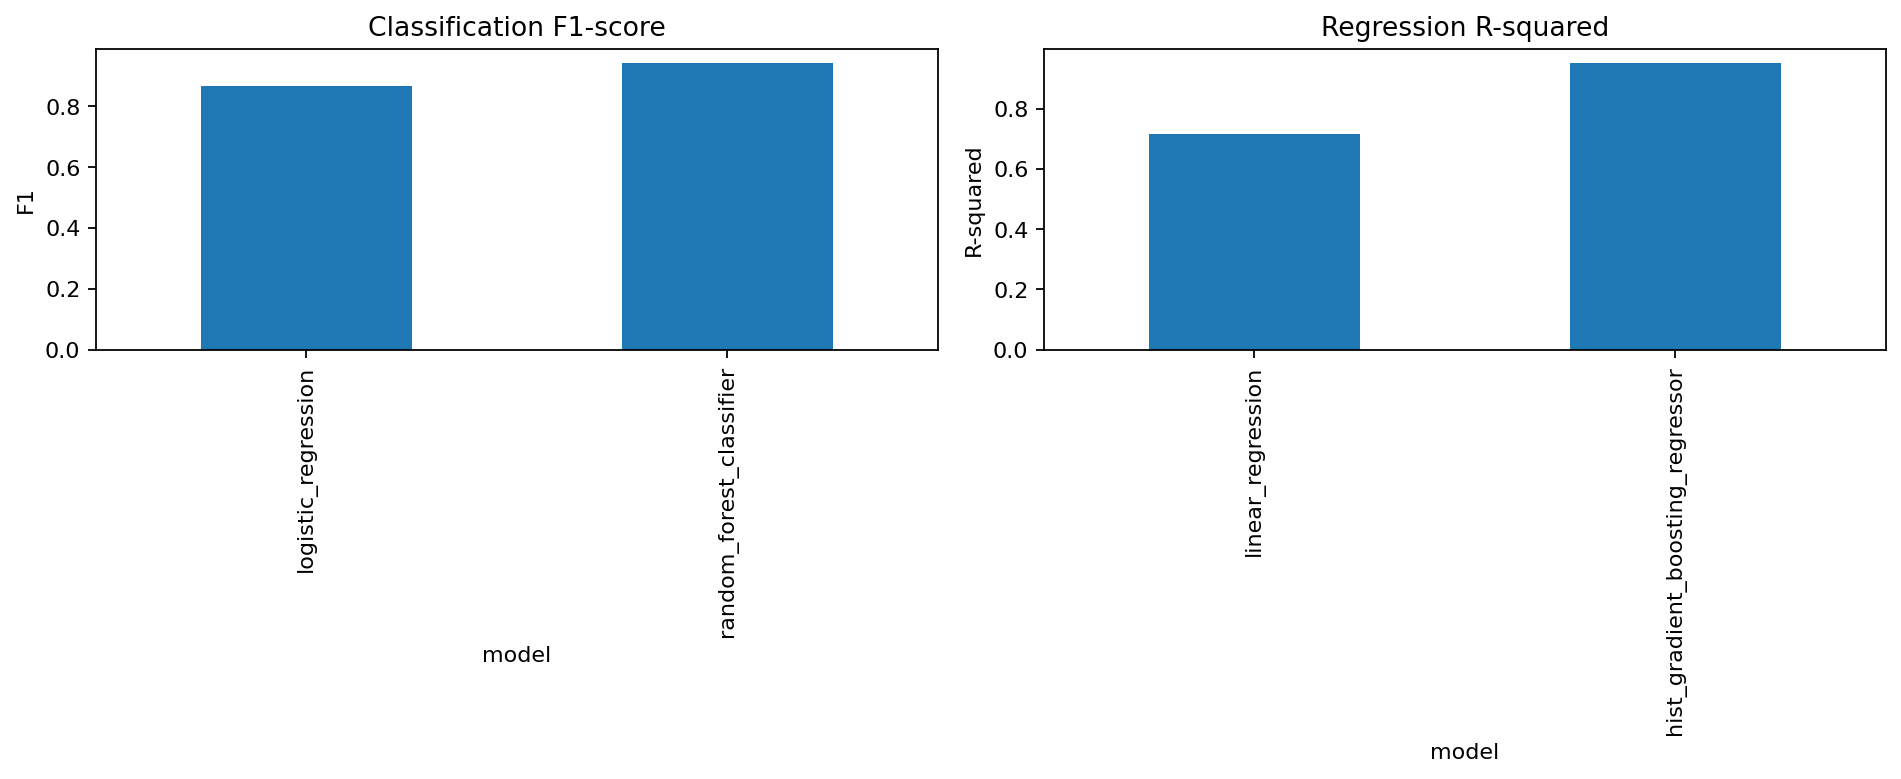

In [30]:
from IPython.display import Image, display
display(Image(filename="/content/capstone_part3/figures/task1_model_comparison.png"))


In [31]:
!tail -n 40 /content/capstone_part3/logs/task1.log


2026-09-24 14:05:51 | INFO | __main__ | Saved classification model: models/random_forest_classifier.joblib
2026-09-24 14:05:52 | INFO | __main__ | Saved regression model: models/linear_regression.joblib
2026-09-24 14:05:56 | INFO | __main__ | Saved regression model: models/hist_gradient_boosting_regressor.joblib
2026-09-24 14:05:56 | INFO | __main__ | Saved Task 1 metrics: results/task1_model_metrics.csv
2026-09-24 14:05:57 | INFO | __main__ | Figure saved: figures/task1_model_comparison.png
2026-09-24 14:05:57 | INFO | __main__ | Part 3 Task 1 completed successfully
2026-09-24 14:05:57 | INFO | __main__ | Classification metrics summary: [{'task': 'classification', 'model': 'logistic_regression', 'accuracy': 0.9655530192986097, 'precision': 0.7747093023255814, 'recall': 0.9797794117647058, 'f1': 0.8652597402597403, 'roc_auc': 0.9934830796353629, 'mae': nan, 'r2': nan}, {'task': 'classification', 'model': 'random_forest_classifier', 'accuracy': 0.9867192363560905, 'precision': 0.9363636

# Task 2 – Unsupervised Machine Learning

K-means clustering is used to group traffic conditions, with the number of clusters selected using silhouette score. Association-rule mining analyses combinations of time period, day type and weather that are associated with congestion categories. Rules are interpreted as **associations, not causal effects**.

In [32]:
%cd /content/capstone_part3
!python task2_unsupervised.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --log logs/task2.log \
  --log-level INFO


/content/capstone_part3
2026-09-24 14:08:40,194 | INFO | __main__ | Part 3 Task 2 unsupervised learning started
2026-09-24 14:08:40,270 | INFO | __main__ | Loaded Task 2 input: 48187 rows x 9 columns
2026-09-24 14:08:40,317 | INFO | __main__ | Congestion quartiles: Q1=1192.500, Q2=3379.000, Q3=4933.000
2026-09-24 14:08:42,370 | INFO | __main__ | K-means candidate k=2 silhouette=0.3725
2026-09-24 14:08:44,799 | INFO | __main__ | K-means candidate k=3 silhouette=0.3907
2026-09-24 14:08:46,590 | INFO | __main__ | K-means candidate k=4 silhouette=0.3853
2026-09-24 14:08:48,407 | INFO | __main__ | K-means candidate k=5 silhouette=0.3895
2026-09-24 14:08:50,175 | INFO | __main__ | K-means candidate k=6 silhouette=0.4112
2026-09-24 14:08:51,329 | INFO | __main__ | Selected k=6 with silhouette=0.4112; saved cluster summaries
2026-09-24 14:08:51,537 | INFO | __main__ | Mined 125 congestion association rules; highest lift 3.663
2026-09-24 14:08:52,001 | INFO | __main__ | Figure saved: figures/ta

In [33]:
clusters = pd.read_csv("/content/capstone_part3/results/task2_cluster_summary.csv")
print("K-means cluster summary")
display(clusters)

rules = pd.read_csv("/content/capstone_part3/results/task2_association_rules.csv")
print("Top association rules by lift")
display(rules[["antecedent", "consequent", "support", "confidence", "lift"]].head(10))


K-means cluster summary


,cluster,records,avg_hour,avg_weather_severity,avg_traffic,share_pct,dominant_time_period,dominant_weather,dominant_congestion,interpretation
0,0,5137,10.571150,1.456492,4742.831419,10.660552,Midday,Mist,Severe,Midday conditions with Severe traffic; dominan...
1,1,8919,20.819262,0.088463,2565.833277,18.509141,Late Evening,Clouds,Medium,Late Evening conditions with Medium traffic; d...
2,2,9225,9.314038,0.000000,4789.169431,19.144168,Morning,Clouds,Severe,Morning conditions with Severe traffic; domina...
3,3,5488,7.442420,1.451713,1136.546647,11.388964,Overnight,Mist,Low,Overnight conditions with Low traffic; dominan...
4,4,9384,2.827366,0.000000,850.414855,19.474132,Overnight,Clear,Low,Overnight conditions with Low traffic; dominan...
5,5,10034,15.540562,0.073650,5125.062587,20.823044,Evening Peak,Clouds,Severe,Evening Peak conditions with Severe traffic; d...


Top association rules by lift


,antecedent,consequent,support,confidence,lift
0,time_period=Overnight AND day_type=Weekend AND...,congestion_category=Low,0.010605,0.915771,3.663006
1,time_period=Overnight AND day_type=Weekend,congestion_category=Low,0.064416,0.886098,3.544317
2,time_period=Overnight AND day_type=Weekend AND...,congestion_category=Low,0.013759,0.884000,3.535927
3,time_period=Overnight AND weather_main=Snow,congestion_category=Low,0.013448,0.869799,3.479122
4,time_period=Morning AND day_type=Weekday AND w...,congestion_category=Severe,0.012285,0.864234,3.459734
5,time_period=Overnight AND day_type=Weekend AND...,congestion_category=Low,0.021977,0.863081,3.452251
6,time_period=Late Evening AND day_type=Weekday ...,congestion_category=Medium,0.031461,0.855048,3.419553
7,time_period=Morning AND day_type=Weekday AND w...,congestion_category=Severe,0.024675,0.853553,3.416979
8,time_period=Overnight AND weather_main=Clouds,congestion_category=Low,0.049225,0.852624,3.410425
9,time_period=Overnight AND weather_main=Clear,congestion_category=Low,0.069583,0.851231,3.404854


task2_k_selection.png


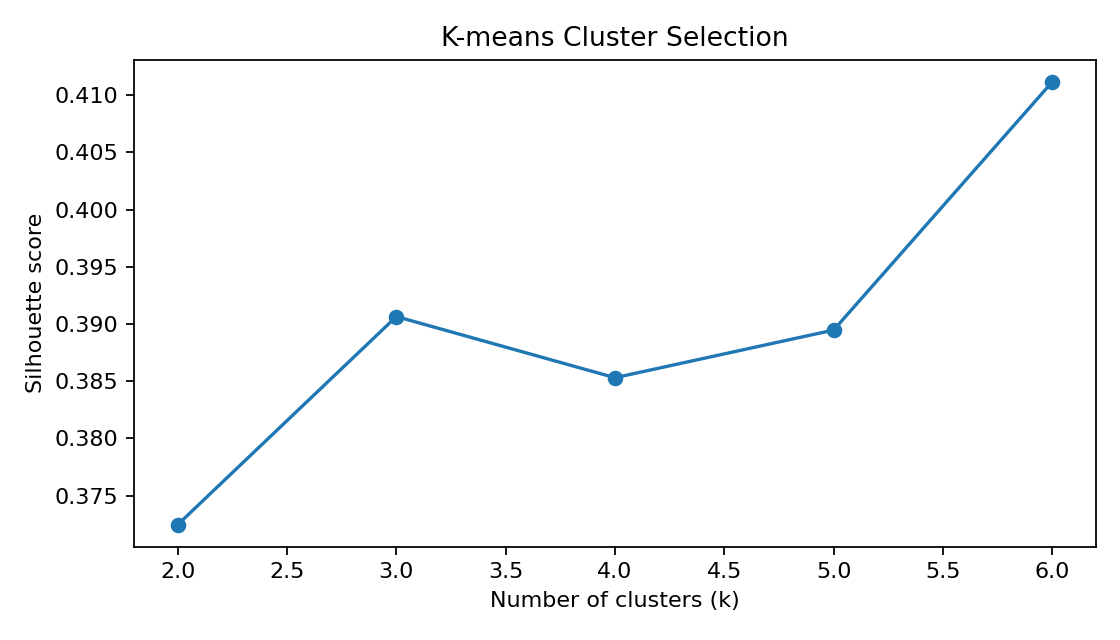

task2_cluster_traffic.png


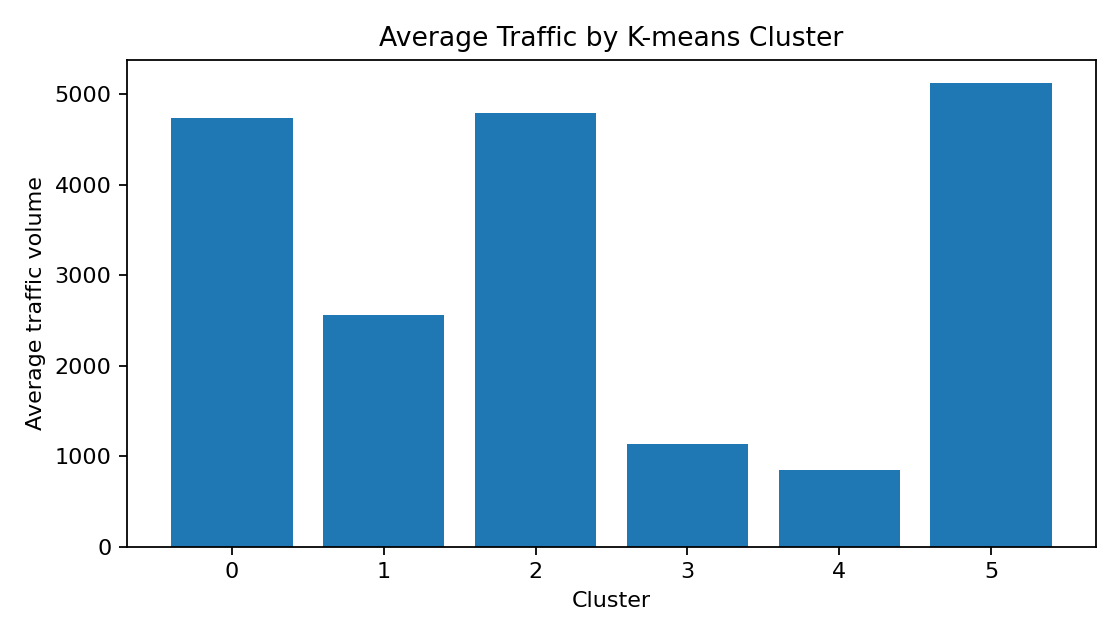

task2_top_rules.png


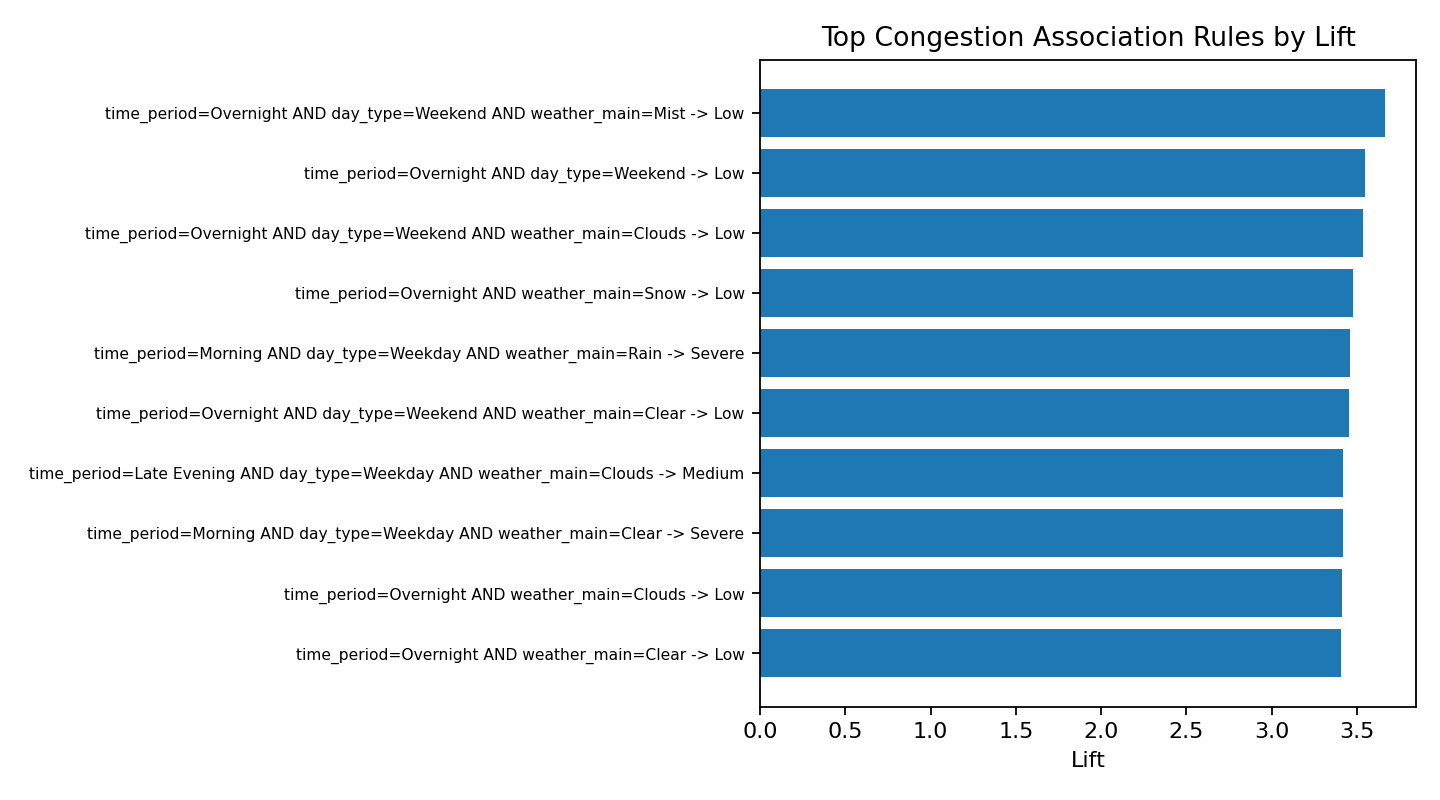

In [34]:
for fn in ["task2_k_selection.png", "task2_cluster_traffic.png", "task2_top_rules.png"]:
    print(fn)
    display(Image(filename=f"/content/capstone_part3/figures/{fn}"))


In [35]:
!tail -n 40 /content/capstone_part3/logs/task2.log


2026-09-24 14:08:40,194 | INFO | __main__ | Part 3 Task 2 unsupervised learning started
2026-09-24 14:08:40,270 | INFO | __main__ | Loaded Task 2 input: 48187 rows x 9 columns
2026-09-24 14:08:40,317 | INFO | __main__ | Congestion quartiles: Q1=1192.500, Q2=3379.000, Q3=4933.000
2026-09-24 14:08:42,370 | INFO | __main__ | K-means candidate k=2 silhouette=0.3725
2026-09-24 14:08:44,799 | INFO | __main__ | K-means candidate k=3 silhouette=0.3907
2026-09-24 14:08:46,590 | INFO | __main__ | K-means candidate k=4 silhouette=0.3853
2026-09-24 14:08:48,407 | INFO | __main__ | K-means candidate k=5 silhouette=0.3895
2026-09-24 14:08:50,175 | INFO | __main__ | K-means candidate k=6 silhouette=0.4112
2026-09-24 14:08:51,329 | INFO | __main__ | Selected k=6 with silhouette=0.4112; saved cluster summaries
2026-09-24 14:08:51,537 | INFO | __main__ | Mined 125 congestion association rules; highest lift 3.663
2026-09-24 14:08:52,001 | INFO | __main__ | Figure saved: figures/task2_k_selection.png
2026

# Task 3 – Deep Learning and Explainability

A multilayer perceptron (MLP) neural network predicts traffic demand. SHAP explainability is applied to a comparable Random Forest regressor trained on the same problem, as permitted by the brief when direct neural-network explanation is less practical. The SHAP result is interpreted as feature influence, not causation.

In [36]:
%cd /content/capstone_part3
!python task3_deep_learning.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --log logs/task3.log \
  --log-level INFO


/content/capstone_part3
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [37]:
nn_metrics = pd.read_csv("/content/capstone_part3/results/task3_neural_network_metrics.csv")
shap_results = pd.read_csv("/content/capstone_part3/results/task3_shap_feature_importance.csv")
print("Neural network metrics")
display(nn_metrics)
print("Top SHAP features")
display(shap_results.head(15))


Neural network metrics


,model,mae,r2,iterations,hidden_layers,random_state
0,MLPRegressor_neural_network,282.002654,0.946808,300,"32,16",42


Top SHAP features


,feature,mean_abs_shap
0,hour_cos,1438.582108
1,hour,427.928366
2,hour_sin,202.507588
3,day_of_week_sin,151.163509
4,is_weekend,140.268497
5,day_of_week,125.479486
6,temp,109.392507
7,day_of_week_cos,62.413379
8,clouds_all,28.110549
9,weather_Clouds,9.040966


task3_neural_network_predictions.png


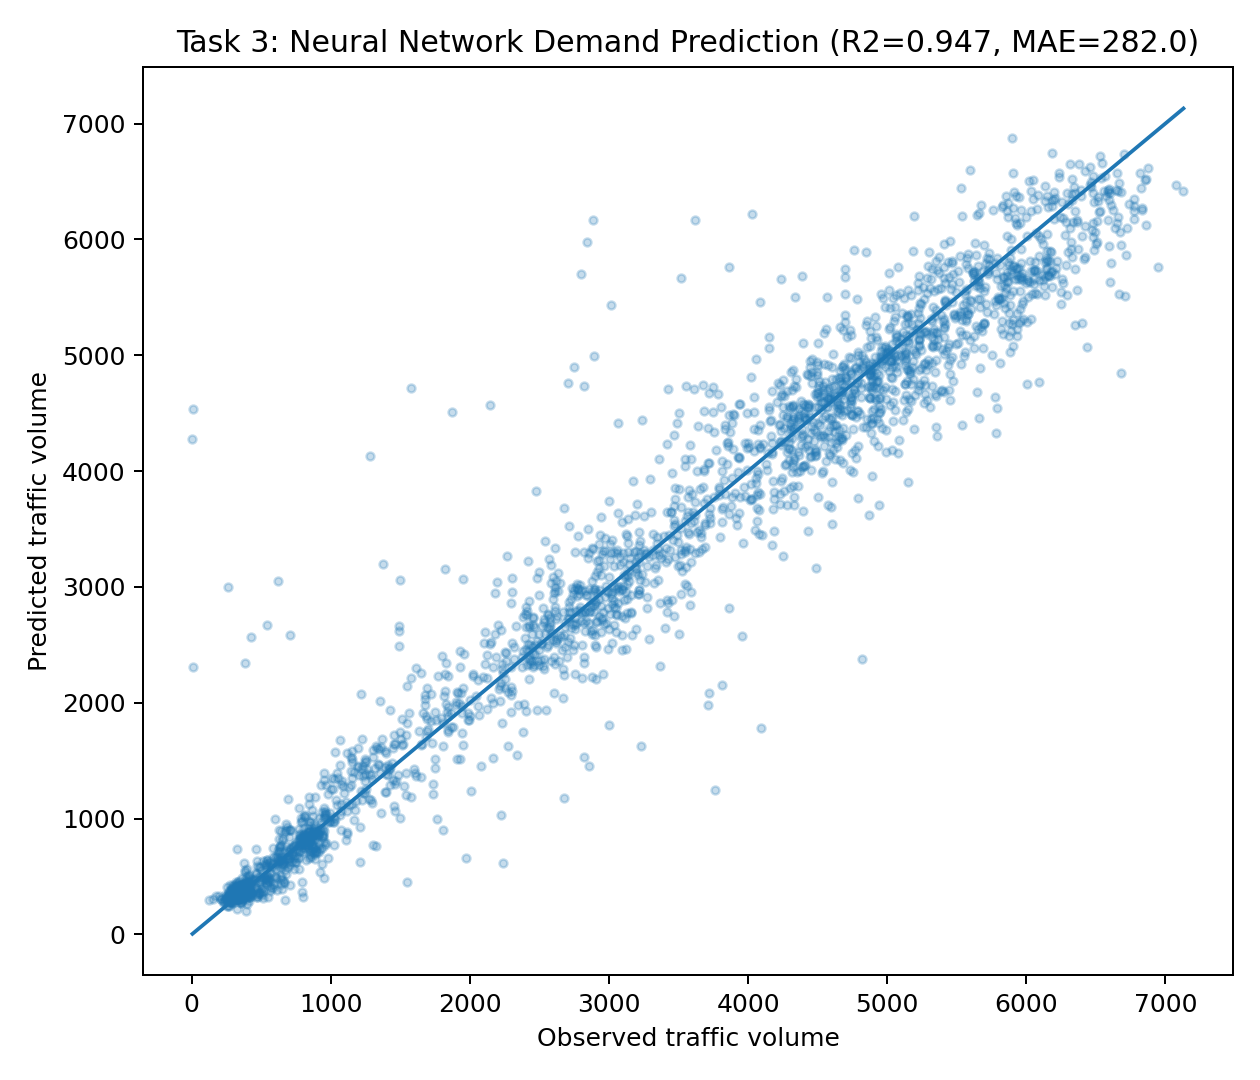

task3_shap_feature_importance.png


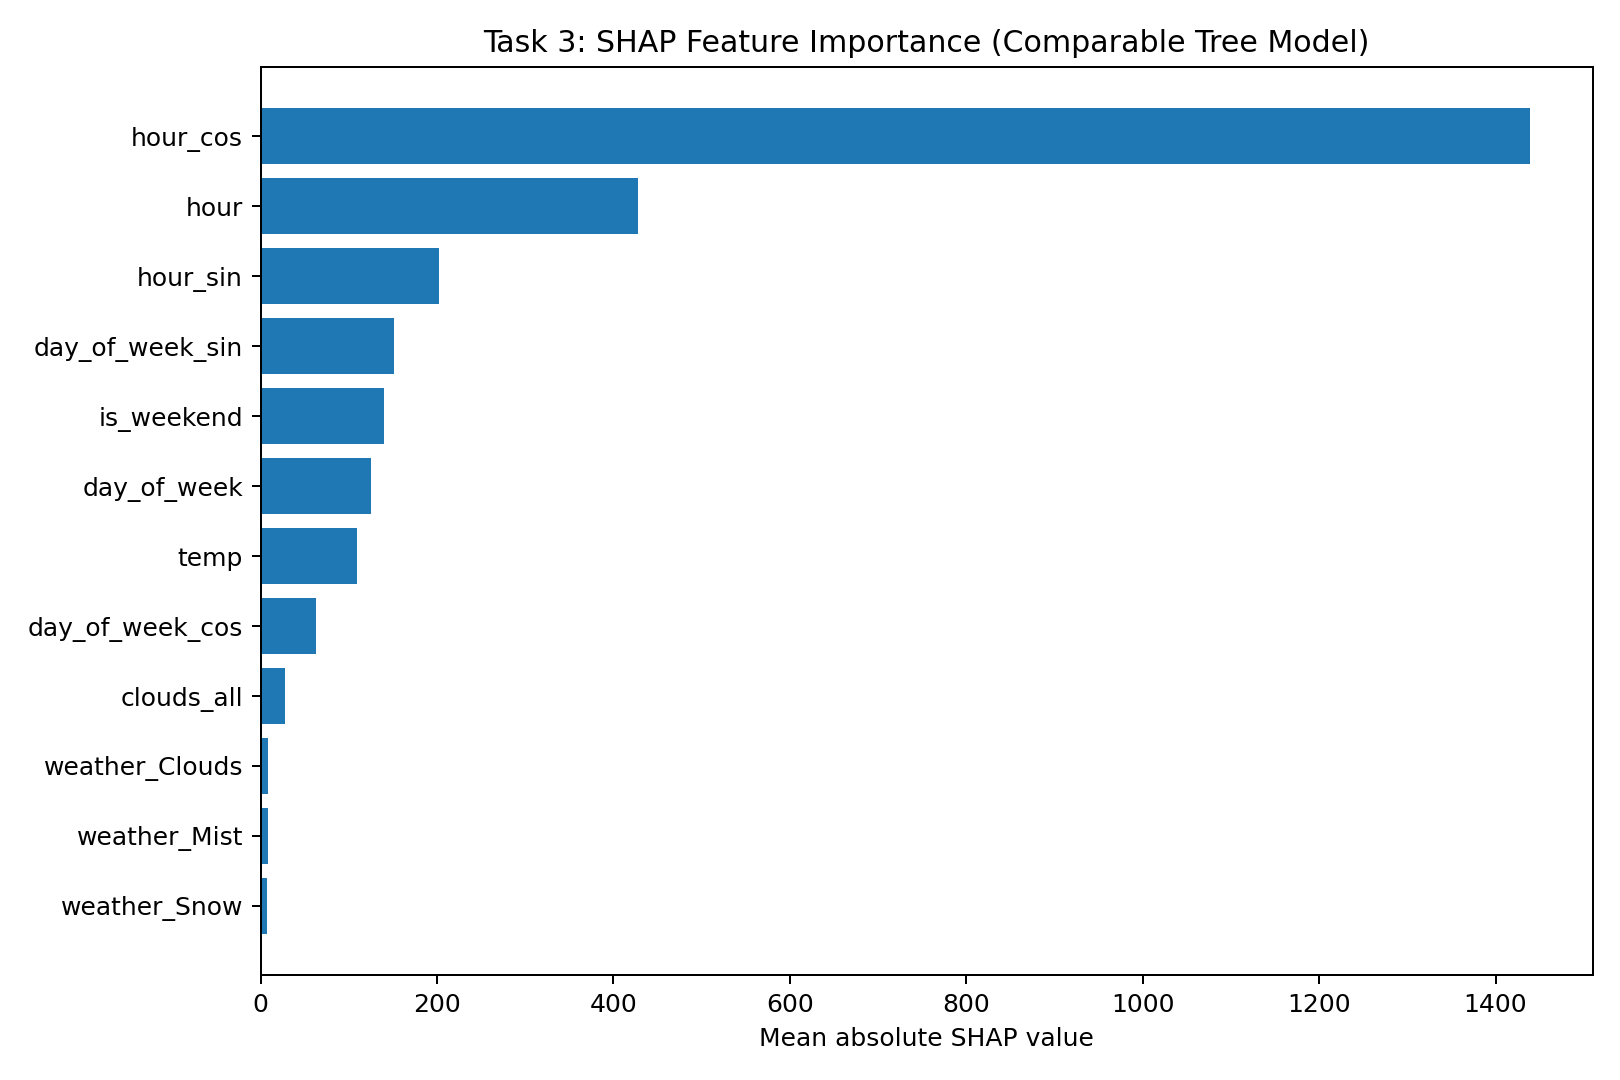

In [38]:
for fn in ["task3_neural_network_predictions.png", "task3_shap_feature_importance.png"]:
    print(fn)
    display(Image(filename=f"/content/capstone_part3/figures/{fn}"))


In [39]:
!tail -n 40 /content/capstone_part3/logs/task3.log


2026-09-24 14:09:00,280 | INFO | __main__ | Part 3 Task 3 deep learning started
2026-09-24 14:09:00,438 | INFO | __main__ | Loaded input dataset: 48187 rows x 9 columns
2026-09-24 14:09:00,546 | INFO | __main__ | Built Task 3 feature set: 48187 rows x 23 features
2026-09-24 14:09:00,546 | INFO | __main__ | Feature set includes time, weather encodings, holiday flag, and cyclical hour/day features
2026-09-24 14:09:00,558 | INFO | __main__ | Sampled 12000 observations for efficient neural-network training
2026-09-24 14:09:00,562 | INFO | __main__ | Train/test split created: train=9600, test=2400
2026-09-24 14:09:00,571 | INFO | __main__ | Feature scaling completed for neural network
2026-09-24 14:09:14,552 | INFO | __main__ | Neural network trained: iterations=300, MAE=282.0027, R2=0.9468
2026-09-24 14:09:14,556 | INFO | __main__ | Saved neural-network model and scaler
2026-09-24 14:09:14,560 | INFO | __main__ | Saved neural-network metrics: results/task3_neural_network_metrics.csv
2026-0

# Task 4 – Advanced AI Technique: MLflow

MLflow is used to track the four Task 1 models as separate experiment runs. The tracking store uses local SQLite (`mlflow.db`) and the trained `.joblib` files are logged as artifacts. This demonstrates experiment tracking and model-version metadata without relying on the deprecated filesystem tracking backend.

In [40]:
!pip install -q mlflow
%cd /content/capstone_part3
!python task4_mlflow.py \
  --input data/traffic_cleaned.csv \
  --models-dir models \
  --metrics results/task1_model_metrics.csv \
  --output-dir results \
  --tracking-dir mlruns \
  --log logs/task4.log \
  --log-level INFO


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [41]:
runs = pd.read_csv("/content/capstone_part3/results/task4_mlflow_runs.csv")
display(runs)


,run_id,run_name,task,model,model_version,metrics
0,eb01eee78f0349ea95ca22f88627e95d,classification-logistic_regression,classification,logistic_regression,task1-v1-logistic_regression,"{'accuracy': 0.9655530192986096, 'precision': ..."
1,fe420bb775944881b727011227a98023,classification-random_forest_classifier,classification,random_forest_classifier,task1-v1-random_forest_classifier,"{'accuracy': 0.9867192363560904, 'precision': ..."
2,750a266e86fe4cb1a70aeee09d00a19a,regression-linear_regression,regression,linear_regression,task1-v1-linear_regression,"{'mae': 818.0308132628202, 'r2': 0.71487356459..."
3,570b06ed83ec4312b0ef26b65af60d23,regression-hist_gradient_boosting_regressor,regression,hist_gradient_boosting_regressor,task1-v1-hist_gradient_boosting_regressor,"{'mae': 257.6017087561784, 'r2': 0.95067726530..."


In [42]:
!tail -n 40 /content/capstone_part3/logs/task4.log


2026-09-24 14:09:53,110 | INFO | __main__ | Part 3 Task 4 MLflow tracking started
2026-09-24 14:09:53,243 | INFO | __main__ | Loaded Task 4 dataset: 48187 rows x 9 columns
2026-09-24 14:09:53,243 | INFO | __main__ | Loaded Task 1 metrics: 4 model records
2026-09-24 14:09:53,326 | INFO | __main__ | MLflow tracking URI: sqlite:///mlflow.db
2026-09-24 14:09:58,883 | INFO | __main__ | MLflow experiment ready: Smart City Traffic Intelligence - Part 3 (id=1)
2026-09-24 14:10:00,177 | INFO | __main__ | MLflow run saved: model=logistic_regression task=classification run_id=eb01eee78f0349ea95ca22f88627e95d metrics={'accuracy': 0.9655530192986096, 'precision': 0.7747093023255814, 'recall': 0.9797794117647058, 'f1': 0.8652597402597403, 'roc_auc': 0.9934830796353628}
2026-09-24 14:10:00,659 | INFO | __main__ | MLflow run saved: model=random_forest_classifier task=classification run_id=fe420bb775944881b727011227a98023 metrics={'accuracy': 0.9867192363560904, 'precision': 0.9363636363636364, 'recall

In [43]:
!find /content/capstone_part3/mlruns -maxdepth 3 -type f | head -30
!ls -lh /content/capstone_part3/mlflow.db


-rw-r--r-- 1 root root 856K Sep 24 14:10 /content/capstone_part3/mlflow.db


# Task 5 – Traffic Recommendation System

Because the data represent a single corridor, the system recommends **travel timing windows** rather than alternative routes. It supports day-type and weather filters and generates plain-language recommendations based on historical traffic volumes.

In [44]:
%cd /content/capstone_part3
!python task5_recommendation.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --day-type Weekday \
  --weather Any \
  --window-hours 1 \
  --top-n 3 \
  --log logs/task5.log \
  --log-level INFO


/content/capstone_part3
2026-09-24 14:10:04,250 | INFO | __main__ | Part 3 Task 5 traffic recommendation started
2026-09-24 14:10:04,380 | INFO | __main__ | Loaded recommendation input: 48187 rows x 9 columns
2026-09-24 14:10:04,480 | INFO | __main__ | Prepared recommendation dataset: 48187 rows
2026-09-24 14:10:04,493 | INFO | __main__ | Applied filters: day_type=Weekday weather=Any -> 34487 observations
2026-09-24 14:10:04,531 | INFO | __main__ | Recommendation 1: For a weekday journey, consider travelling between 02:00-03:00, when historical traffic volumes average about 302 vehicles/hour.
2026-09-24 14:10:04,531 | INFO | __main__ | Recommendation 2: For a weekday journey, consider travelling between 03:00-04:00, when historical traffic volumes average about 362 vehicles/hour.
2026-09-24 14:10:04,532 | INFO | __main__ | Recommendation 3: For a weekday journey, consider travelling between 01:00-02:00, when historical traffic volumes average about 397 vehicles/hour.
2026-09-24 14:10:0

In [45]:
recs = pd.read_csv("/content/capstone_part3/results/task5_recommendations.csv")
display(recs)


,start_hour,end_hour,window,avg_traffic,observations,recommendation
0,2,2,02:00-03:00,301.982818,1455,"For a weekday journey, consider travelling bet..."
1,3,3,03:00-04:00,362.289835,1456,"For a weekday journey, consider travelling bet..."
2,1,1,01:00-02:00,396.913043,1449,"For a weekday journey, consider travelling bet..."


In [46]:
# Optional weather-specific demonstration
!python task5_recommendation.py \
  --input data/traffic_cleaned.csv \
  --output-dir . \
  --day-type Weekday \
  --weather Rain \
  --window-hours 1 \
  --top-n 3 \
  --log logs/task5_rain.log \
  --log-level INFO


2026-09-24 14:10:07,762 | INFO | __main__ | Part 3 Task 5 traffic recommendation started
2026-09-24 14:10:07,841 | INFO | __main__ | Loaded recommendation input: 48187 rows x 9 columns
2026-09-24 14:10:07,902 | INFO | __main__ | Prepared recommendation dataset: 48187 rows
2026-09-24 14:10:07,919 | INFO | __main__ | Applied filters: day_type=Weekday weather=Rain -> 4153 observations
2026-09-24 14:10:07,940 | INFO | __main__ | Recommendation 1: For a weekday under Rain weather journey, consider travelling between 02:00-03:00, when historical traffic volumes average about 299 vehicles/hour.
2026-09-24 14:10:07,940 | INFO | __main__ | Recommendation 2: For a weekday under Rain weather journey, consider travelling between 03:00-04:00, when historical traffic volumes average about 364 vehicles/hour.
2026-09-24 14:10:07,940 | INFO | __main__ | Recommendation 3: For a weekday under Rain weather journey, consider travelling between 01:00-02:00, when historical traffic volumes average about 399 

In [47]:
!tail -n 30 /content/capstone_part3/logs/task5.log


2026-09-24 14:10:04,250 | INFO | __main__ | Part 3 Task 5 traffic recommendation started
2026-09-24 14:10:04,380 | INFO | __main__ | Loaded recommendation input: 48187 rows x 9 columns
2026-09-24 14:10:04,480 | INFO | __main__ | Prepared recommendation dataset: 48187 rows
2026-09-24 14:10:04,493 | INFO | __main__ | Applied filters: day_type=Weekday weather=Any -> 34487 observations
2026-09-24 14:10:04,531 | INFO | __main__ | Recommendation 1: For a weekday journey, consider travelling between 02:00-03:00, when historical traffic volumes average about 302 vehicles/hour.
2026-09-24 14:10:04,531 | INFO | __main__ | Recommendation 2: For a weekday journey, consider travelling between 03:00-04:00, when historical traffic volumes average about 362 vehicles/hour.
2026-09-24 14:10:04,532 | INFO | __main__ | Recommendation 3: For a weekday journey, consider travelling between 01:00-02:00, when historical traffic volumes average about 397 vehicles/hour.
2026-09-24 14:10:05,635 | INFO | __main__ 

# Task 6 – MLOps and Deployment Simulation

This section covers model versioning, MLflow tracking, a FastAPI mock deployment, feature/prediction drift monitoring, and PASS/ALERT reporting.

In [48]:
%cd /content/capstone_part3
!pip install -q fastapi uvicorn httpx

!python task6_mlop.py \
  --input data/traffic_cleaned.csv \
  --models-dir models \
  --metrics results/task1_model_metrics.csv \
  --output-dir results \
  --tracking-db mlflow.db \
  --log logs/task6.log \
  --log-level INFO


/content/capstone_part3
2026-09-24 14:10:20,495 | INFO | __main__ | Part 3 Task 6 MLOps simulation started
2026-09-24 14:10:20,645 | INFO | __main__ | Loaded monitoring dataset: 48187 rows x 9 columns
2026-09-24 14:10:20,652 | INFO | __main__ | Saved model version registry: results/task6_model_version_registry.csv (4 records)
2026-09-24 14:10:23,190 | WARNING | __main__ | Monitoring alert triggered: Feature drift: clouds_all PSI=0.508
2026-09-24 14:10:23,191 | INFO | __main__ | Saved monitoring report: results/task6_monitoring_report.json
2026-09-24 14:10:24,776 | INFO | __main__ | MLflow deployment/monitoring run saved: 30988f9cb6d64bf38aa6fffca0972672
2026-09-24 14:10:24,792 | WARNING | __main__ | Task 6 completed with monitoring status ALERT / Requires investigation
2026-09-24 14:10:24,792 | INFO | __main__ | Task 6 MLOps simulation completed successfully


In [49]:
version_registry = pd.read_csv("/content/capstone_part3/results/task6_model_version_registry.csv")
display(version_registry)


,model_version,model,task,status,artifact,accuracy,precision,recall,f1,roc_auc,mae,r2
0,task1-v1-logistic_regression,logistic_regression,classification,validated,models/logistic_regression.joblib,0.965553,0.774709,0.979779,0.865260,0.993483,NaN,NaN
1,task1-v1-random_forest_classifier,random_forest_classifier,classification,validated,models/random_forest_classifier.joblib,0.986719,0.936364,0.946691,0.941499,0.998167,NaN,NaN
2,task1-v1-linear_regression,linear_regression,regression,validated,models/linear_regression.joblib,NaN,NaN,NaN,NaN,NaN,818.030813,0.714874
3,task1-v1-hist_gradient_boosting_regressor,hist_gradient_boosting_regressor,regression,validated,models/hist_gradient_boosting_regressor.joblib,NaN,NaN,NaN,NaN,NaN,257.601709,0.950677


In [50]:
import json
with open("/content/capstone_part3/results/task6_monitoring_report.json", "r", encoding="utf-8") as f:
    monitoring = json.load(f)
display(monitoring)


{'model_version': 'task1-v1-hist_gradient_boosting_regressor',
 'monitoring_method': 'chronological baseline/current comparison',
 'baseline_rows': 33730,
 'current_rows': 14457,
 'baseline_mae': 255.230548827392,
 'current_mae': 228.19218691831742,
 'mae_ratio': 0.8940629872352774,
 'psi_threshold_alert': 0.2,
 'feature_psi': {'hour': 0.00011157528374507385,
  'day_of_week': 0.00046226044093959954,
  'month': 0.18958381932647148,
  'temp': 0.14459509178699567,
  'rain_1h': 0.016451302844182808,
  'snow_1h': 0.008085210785829836,
  'clouds_all': 0.5081586741892994,
  'weather_main': 0.03174373406078037,
  'weather_description': 0.3042623457989041,
  'holiday': 0.00047639515861144083},
 'max_psi_feature': 'clouds_all',
 'max_psi': 0.5081586741892994,
 'alert_if_mae_ratio_ge': 1.5,
 'status': 'ALERT / Requires investigation',
 'alerts': ['Feature drift: clouds_all PSI=0.508'],
 'note': 'Monitoring is a capstone simulation using chronological slices of the supplied corridor dataset; thres

In [51]:
!cat /content/capstone_part3/logs/task6.log


2026-09-24 14:10:20,495 | INFO | __main__ | Part 3 Task 6 MLOps simulation started
2026-09-24 14:10:20,645 | INFO | __main__ | Loaded monitoring dataset: 48187 rows x 9 columns
2026-09-24 14:10:20,652 | INFO | __main__ | Saved model version registry: results/task6_model_version_registry.csv (4 records)
2026-09-24 14:10:23,190 | WARNING | __main__ | Monitoring alert triggered: Feature drift: clouds_all PSI=0.508
2026-09-24 14:10:23,191 | INFO | __main__ | Saved monitoring report: results/task6_monitoring_report.json
2026-09-24 14:10:24,776 | INFO | __main__ | MLflow deployment/monitoring run saved: 30988f9cb6d64bf38aa6fffca0972672
2026-09-24 14:10:24,792 | WARNING | __main__ | Task 6 completed with monitoring status ALERT / Requires investigation
2026-09-24 14:10:24,792 | INFO | __main__ | Task 6 MLOps simulation completed successfully


In [52]:
!python task6_api_test.py \
  --model models/hist_gradient_boosting_regressor.joblib \
  --log logs/task6_api.log


2026-09-24 14:10:28,947 | INFO | httpx2 | HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-09-24 14:10:28,947 | INFO | __main__ | Health response: {'status': 'ok', 'model_version': 'task1-v1-hist_gradient_boosting_regressor'}
2026-09-24 14:10:29,048 | INFO | task6_api | API prediction generated for 2017-08-01T16:00:00: 6432.68 vehicles/hour
2026-09-24 14:10:29,052 | INFO | httpx2 | HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-09-24 14:10:29,052 | INFO | __main__ | Prediction response: {'model_version': 'task1-v1-hist_gradient_boosting_regressor', 'prediction_traffic_volume': 6432.68, 'units': 'vehicles/hour'}
{'model_version': 'task1-v1-hist_gradient_boosting_regressor', 'prediction_traffic_volume': 6432.68, 'units': 'vehicles/hour'}


In [53]:
!cat /content/capstone_part3/logs/task6_api.log


2026-09-24 14:10:28,947 | INFO | httpx2 | HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-09-24 14:10:28,947 | INFO | __main__ | Health response: {'status': 'ok', 'model_version': 'task1-v1-hist_gradient_boosting_regressor'}
2026-09-24 14:10:29,048 | INFO | task6_api | API prediction generated for 2017-08-01T16:00:00: 6432.68 vehicles/hour
2026-09-24 14:10:29,052 | INFO | httpx2 | HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-09-24 14:10:29,052 | INFO | __main__ | Prediction response: {'model_version': 'task1-v1-hist_gradient_boosting_regressor', 'prediction_traffic_volume': 6432.68, 'units': 'vehicles/hour'}


# Final Part 3 Tasks 1–6 Audit

The final notebook should finish with a compact inventory of the generated evidence. Task 7 is submitted separately as the Responsible and Sustainable AI report.

In [54]:
from pathlib import Path

print("=== Scripts ===")
for p in sorted(BASE.glob("*.py")):
    print(p.name)

print("\n=== Results ===")
for p in sorted((BASE / "results").glob("*")):
    print(p.name)

print("\n=== Figures ===")
for p in sorted((BASE / "figures").glob("*")):
    print(p.name)

print("\n=== Logs ===")
for p in sorted((BASE / "logs").glob("*")):
    print(p.name)

print("\n=== Models ===")
for p in sorted((BASE / "models").glob("*")):
    print(p.name)


=== Scripts ===
task1_supervised_models.py
task2_unsupervised.py
task3_deep_learning.py
task4_mlflow.py
task5_recommendation.py
task6_api.py
task6_api_test.py
task6_mlop.py

=== Results ===
task1_model_metrics.csv
task2_association_rules.csv
task2_cluster_assignments.csv
task2_cluster_summary.csv
task2_interpretation.txt
task2_k_selection.csv
task3_neural_network_metrics.csv
task3_shap_feature_importance.csv
task4_mlflow_runs.csv
task4_mlflow_summary.json
task5_filtered_hourly_profile.csv
task5_recommendation_summary.txt
task5_recommendations.csv
task5_recommendations.json
task6_mlop_summary.json
task6_model_version_registry.csv
task6_monitoring_report.json

=== Figures ===
task1_model_comparison.png
task2_cluster_traffic.png
task2_k_selection.png
task2_top_rules.png
task3_neural_network_predictions.png
task3_shap_feature_importance.png
task5_recommended_windows.png

=== Logs ===
task1.log
task2.log
task3.log
task4.log
task5.log
task5_rain.log
task6.log
task6_api.log

=== Models ===
hi

## Final execution summary

**Task 1 – Supervised ML:** completed  
**Task 2 – Unsupervised ML:** completed  
**Task 3 – Deep Learning + SHAP:** completed  
**Task 4 – Advanced AI / MLflow:** completed  
**Task 5 – Recommendation System:** completed  
**Task 6 – MLOps + Deployment + Monitoring:** completed  
**Task 7 – Responsible and Sustainable AI:** submitted separately as a report.